In [5]:
!pip install ucimlrepo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

implementazione a ogetti di una classe per gestire il dataset

In [7]:
class DataExploration:
  def __init__(self, dataset):
    self.dataset = dataset

  def get_dataset(self):
    return self.dataset

  def get_dataset_shape(self):
    return self.dataset.shape

  def get_dataset_info(self):
    return self.dataset.info()

  def get_dataset_describe(self):
    return self.dataset.describe()

  def get_dataset_corr(self):
    numeric_cols = self.dataset.select_dtypes(include='number').columns
    df = self.dataset[numeric_cols]
    return df.corr()

  def replace_strange_missing_values(self):
        # cerca valori strani di missing values e sostituiscili con nan
        strange_tokens = ["?", "Unknown", "unknown", "NAN", "nan", "NA", "na", "", " "]
        return self.dataset.replace(strange_tokens, np.nan)

  def get_dataset_distribution(self, mode = "test"):
    if mode == 'box':
      return self.dataset.boxplot(figsize=(10,10))
    elif mode == 'hist':
      return self.dataset.hist(figsize=(10,10))
    else:
      df = self.replace_strange_missing_values()
      results = {}
      numeric_cols = df.select_dtypes(include='number').columns

      for col in numeric_cols:
          stat, p = jarque_bera(df[col].dropna())
          results[col] = {"stat": stat, "p_value": p}

      return results

  def get_dataset_missing_values(self):
    df = self.replace_strange_missing_values()

    null_values = df.isna().sum()
    miss_percent = df.isna().sum() * 100 / len(df)
    return null_values, miss_percent

  def replace_missing_values(self, method, column, value=0):
    df = self.replace_strange_missing_values()

    for col in column:
      if method == 'mean':
          df[col] = df[col].fillna(df[col].mean())
      elif method == 'median':
          df[col] = df[col].fillna(df[col].median())
      elif method == 'mode':
          df[col] = df[col].fillna(df[col].mode().iloc[0])
      elif method == 'ffill':
          df[col] = df[col].fillna(method='ffill')
      elif method == 'bfill':
          df[col] = df[col].fillna(method='bfill')
      elif method == 'fill':
          df[col] = df[col].fillna(value)
      else:
          df = df.dropna(subset=[col])
    return df

  def delete_dataset_outliers(self, column=None):
    df = self.replace_strange_missing_values()

    numeric_cols = df[column].select_dtypes(include='number').columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df


# utilizzo
data = DataExploration(X)

In [8]:
data.get_dataset_corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
education-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


In [9]:
data.get_dataset_describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

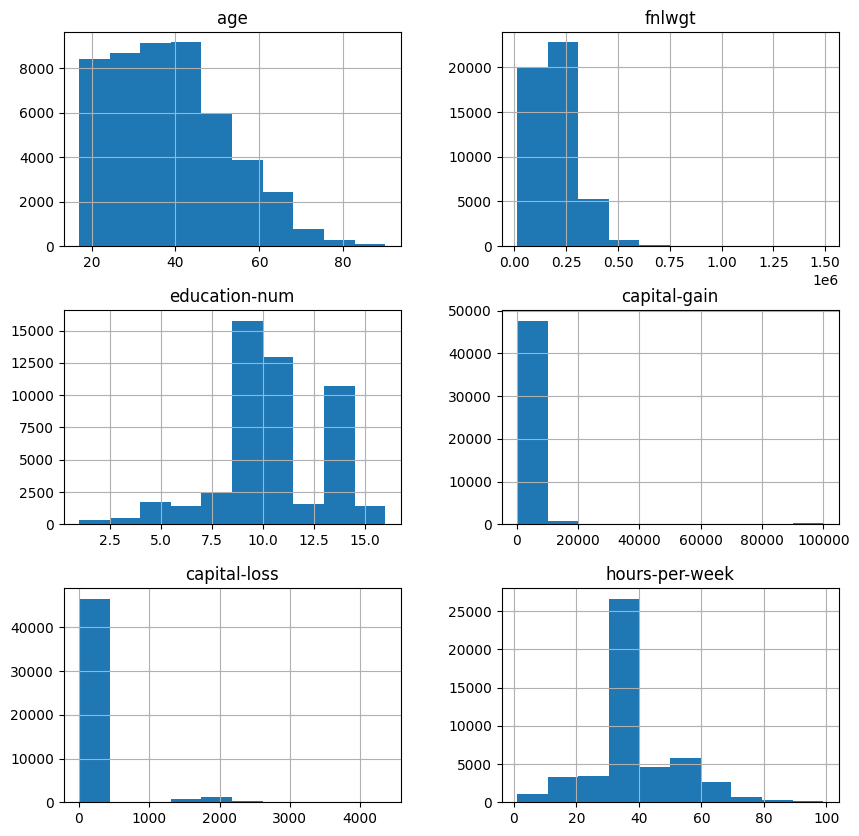

In [10]:
data.get_dataset_distribution(mode="hist")

In [11]:
data.get_dataset_distribution()

{'age': {'stat': np.float64(2599.8192722344797), 'p_value': np.float64(0.0)},
 'fnlwgt': {'stat': np.float64(91516.99451625564), 'p_value': np.float64(0.0)},
 'education-num': {'stat': np.float64(1611.8889827432),
  'p_value': np.float64(0.0)},
 'capital-gain': {'stat': np.float64(48590194.71256326),
  'p_value': np.float64(0.0)},
 'capital-loss': {'stat': np.float64(985010.047192478),
  'p_value': np.float64(0.0)},
 'hours-per-week': {'stat': np.float64(18181.90968669491),
  'p_value': np.float64(0.0)}}

In [12]:
data.get_dataset_missing_values()

(age                  0
 workclass         2799
 fnlwgt               0
 education            0
 education-num        0
 marital-status       0
 occupation        2809
 relationship         0
 race                 0
 sex                  0
 capital-gain         0
 capital-loss         0
 hours-per-week       0
 native-country     857
 dtype: int64,
 age               0.000000
 workclass         5.730724
 fnlwgt            0.000000
 education         0.000000
 education-num     0.000000
 marital-status    0.000000
 occupation        5.751198
 relationship      0.000000
 race              0.000000
 sex               0.000000
 capital-gain      0.000000
 capital-loss      0.000000
 hours-per-week    0.000000
 native-country    1.754637
 dtype: float64)

In [13]:
df = data.replace_missing_values(method="bfill", column=["workclass", "occupation"])
df = DataExploration(df)
df.get_dataset_missing_values()

/tmp/ipykernel_2154/3125010625.py:63: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='bfill')


(age                 0
 workclass           0
 fnlwgt              0
 education           0
 education-num       0
 marital-status      0
 occupation          0
 relationship        0
 race                0
 sex                 0
 capital-gain        0
 capital-loss        0
 hours-per-week      0
 native-country    857
 dtype: int64,
 age               0.000000
 workclass         0.000000
 fnlwgt            0.000000
 education         0.000000
 education-num     0.000000
 marital-status    0.000000
 occupation        0.000000
 relationship      0.000000
 race              0.000000
 sex               0.000000
 capital-gain      0.000000
 capital-loss      0.000000
 hours-per-week    0.000000
 native-country    1.754637
 dtype: float64)

<Axes: >

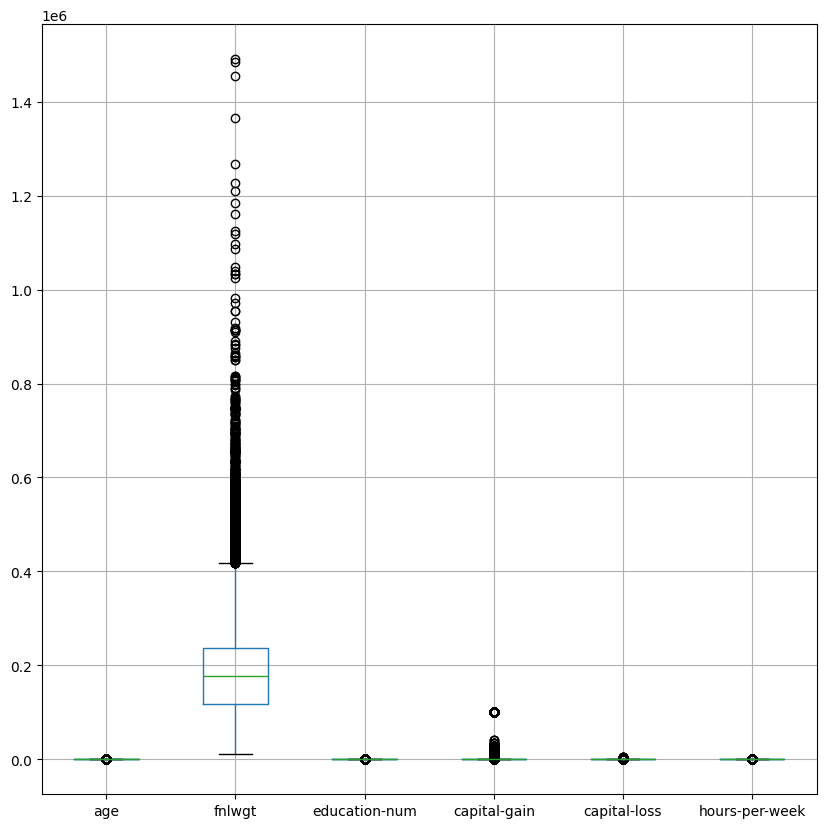

In [14]:
data.get_dataset_distribution(mode='box')

<Axes: >

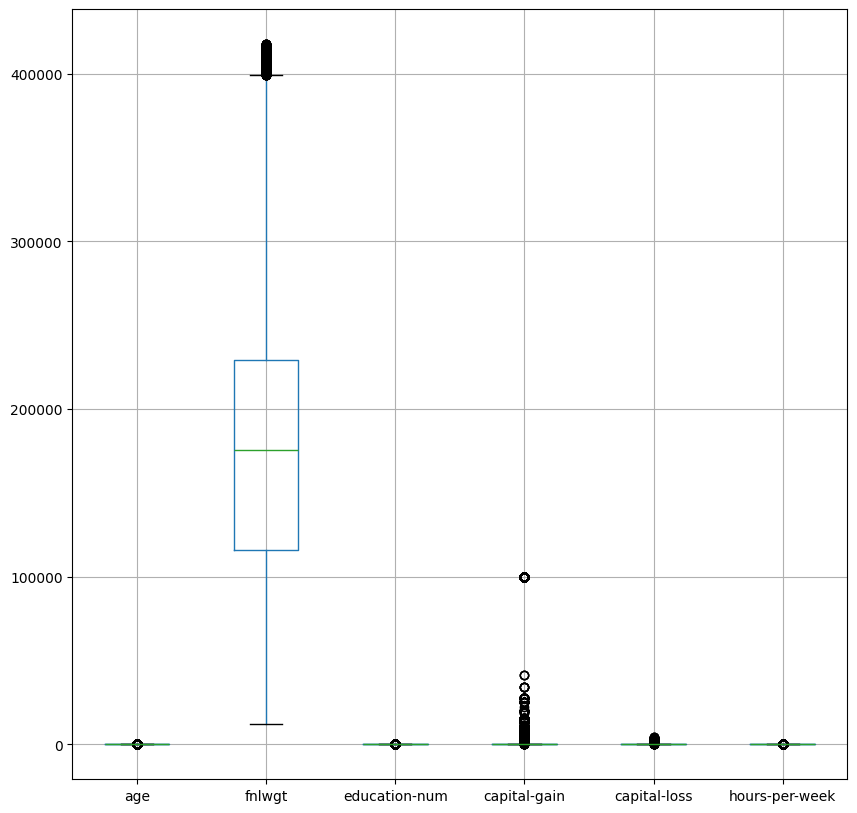

In [15]:
new = data.delete_dataset_outliers(column=["fnlwgt"])
new = DataExploration(new)
new.get_dataset_distribution(mode='box')